## Carrego el dataframe principal

In [2]:
# Carreguem  el DataFrame principal modificat amb les dades netejades i transformades
import pandas as pd
df_principal = pd.read_excel('C:\\LLUIS\Dropbox\\IT ACADEMY\\Sprint13\\df_principal_modificat.xlsx')
df_principal.head(5)

,IDALUMNE,IDCURS,IDEVALUACIO,MATERIA,RESULT,PUNTS,MAXPUNTS,POBLACIO,PAIS,DATANAIXEMENT,SEXO,NRO_EJERCICIO,TOTAL,TIPUS_ESCOLA,PROFE,INICI_CURS,EDAD,DATA_EVALUACIO
0,30,788,53,LISTENING,18.8,16.0,17.0,Barcelona,Espanya,1998-10-30,F,10,72.8,PUBLICA,GUY,2014-09-15,15,2015-06-20
1,30,788,53,LISTENING,18.8,16.0,17.0,Barcelona,Espanya,1998-10-30,F,10,71.6,PUBLICA,GUY,2014-09-15,15,2015-06-20
2,30,788,53,LISTENING,18.8,16.0,17.0,Barcelona,Espanya,1998-10-30,F,10,75.0,PUBLICA,GUY,2014-09-15,15,2015-06-20
3,30,788,53,LISTENING,18.8,16.0,17.0,Barcelona,Espanya,1998-10-30,F,10,68.3,PUBLICA,GUY,2014-09-15,15,2015-06-20
4,30,788,53,LISTENING,18.8,16.0,17.0,Barcelona,Espanya,1998-10-30,F,10,67.5,PUBLICA,GUY,2014-09-15,15,2015-06-20


# Grafics

## El % d'alumnes per sexe

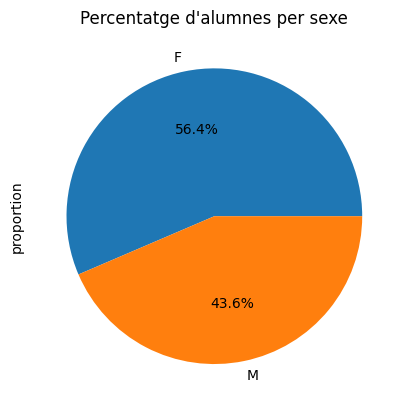

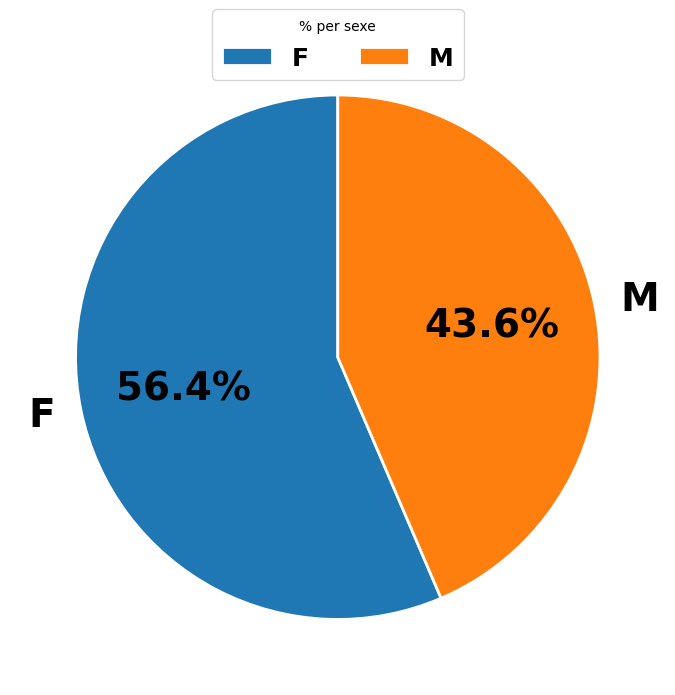


DISTRIBUCIÓN POR SEXO - RESUMEN
F: 56.4%
M: 43.6%

Total alumnos: 276987


In [3]:
# miro el % entre sexe 
df_sexo=df_principal['SEXO'].value_counts(normalize=True) * 100
df_sexo.plot.pie(title='Percentatge d\'alumnes per sexe', autopct='%1.1f%%')
#df_sexo.to_excel('C:\\temp\\df_sexo.xlsx', index=False)


####################################################
# Versión minimalista y elegante
import matplotlib.pyplot as plt

# Calcular porcentajes
df_sexo = df_principal['SEXO'].value_counts(normalize=True) * 100

# Colores minimalistas
#colores_minimalistas = ['#74b9ff', '#fd79a8']  # Azul claro + Rosa
#colores = ['#3498db', '#e74c3c', '#2ecc71', '#f39c12', '#9b59b6']
#colores = ['#2E86AB', '#A23B72', '#F18F01']  # Azul, Rosa, Naranja
colores_minimalistas = ['#1F77B4', '#FF7F0E', '#2CA02C']  # Azul, Naranja, Verde
# Crear figura
plt.figure(figsize=(9, 7))

# Crear gráfico circular simple pero elegante
plt.pie(
    df_sexo.values,
    labels=df_sexo.index,
    colors=colores_minimalistas,
    autopct=lambda pct: f'{pct:.1f}%',
    startangle=90,
    #explode=[0.01, 0],  # Separar ligeramente la primera porción
    shadow=False,  # Sombra suave
    wedgeprops={'edgecolor': 'white', 'linewidth': 2},    
    textprops={
        'fontsize': 28,
        'fontweight': 'bold',
        'color': '#000000'}
)


# Leyenda simple

plt.legend(
    df_sexo.index,  # Nombres de las categorías en la leyenda
    title='% per sexe',
    loc='upper center',  # Colocamos la leyenda arriba
    bbox_to_anchor=(0.5, 1.05),  # Ajusta la posición vertical de la leyenda
    ncol=len(df_sexo),  # Si quieres que las categorías estén en una fila
    frameon=True,
    framealpha=0.8,
    title_fontsize='medium',
    prop={'weight': 'bold', 'size': 18}  # Leyenda en negrita y tamaño más grande
)


# Ajustar layout
plt.tight_layout()
plt.savefig('C:\\temp\\grafico_sexo_minimalista.png', dpi=1200)
plt.show()


# Mostrar estadísticas en consola
print("\n" + "=" * 50)
print("DISTRIBUCIÓN POR SEXO - RESUMEN")
print("=" * 50)
for sexo, porcentaje in df_sexo.items():
    print(f"{sexo}: {porcentaje:.1f}%")
print(f"\nTotal alumnos: {len(df_principal)}")
print("=" * 50)
########################################################


# GRÁFICO 1: DISTRIBUCIÓN DE APROBADOS VS NO APROBADOS (DONUT CHART)

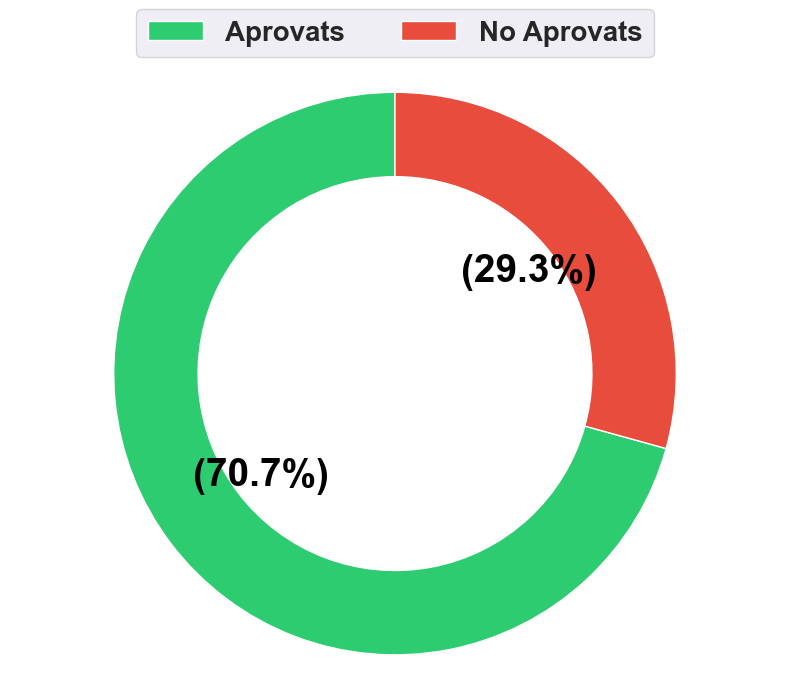

In [4]:
# ============================================================================
# GRÁFICO 1: DISTRIBUCIÓN DE APROBADOS VS NO APROBADOS (DONUT CHART)
# ============================================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
df=df_principal.copy()
# Configuración
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("Set2")

# 1. DATOS GENERALES
# Calcular estadísticas generales
total_estudiantes = len(df)
aprobados = (df['TOTAL'] > 64).sum()
no_aprobados = total_estudiantes - aprobados

porcentaje_aprobados = (aprobados / total_estudiantes) * 100
porcentaje_no_aprobados = 100 - porcentaje_aprobados

# Media ponderada del TOTAL (solo aprobados)
media_total_aprobados = df[df['TOTAL'] > 64]['TOTAL'].mean()
media_total_general = df['TOTAL'].mean()

# Crear DataFrame para visualización
datos_aprobacion = pd.DataFrame({
    'Categoria': ['Aprobats', 'No Aprobats'],
    'Cantidad': [aprobados, no_aprobados],
    'Porcentaje': [porcentaje_aprobados, porcentaje_no_aprobados]
})
datos_aprobacion

# grafic # Donut chart
fig, ax = plt.subplots(figsize=(8, 7))  # Cambiado a un solo eje


colors = ['#2ecc71', '#e74c3c']
wedges, texts, autotexts = ax.pie(
    datos_aprobacion['Cantidad'], 
    #labels=datos_aprobacion['Categoria'],
    autopct=lambda p: f'({p:.1f}%)',
    colors=colors,
    startangle=90,
    wedgeprops=dict(width=0.3, edgecolor='w')
)
#ax.set_title('Distribución de Aprobados/No Aprobados\n(TOTAL > 64)', 
             #fontsize=14, fontweight='bold', pad=20)

# Personalizar texto
for autotext in autotexts:
    autotext.set_color('black')
    autotext.set_fontweight('bold')
    autotext.set_fontsize(28)

# Añadir círculo central para efecto donut
centre_circle = plt.Circle((0,0), 0.70, fc='white')
ax.add_artist(centre_circle)
ax.axis('equal')

# legend
plt.legend(
    ['Aprovats', 'No Aprovats'], #datos_aprobacion.Categoria,  # Nombres de las categorías en la leyenda
    #title='% aprovats',
    loc='center',  # Colocamos la leyenda arriba
    bbox_to_anchor=(0.5, 1.05),  # Ajusta la posición vertical de la leyenda
    ncol=len(datos_aprobacion),  # Si quieres que las categorías estén en una fila
    frameon=True,
    framealpha=0.8,
    title_fontsize='small',
    prop={'weight': 'bold', 'size': 20}  # Leyenda en negrita y tamaño más grande
)
#plt.suptitle(f'Total alumnes', 
#             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig("C:\\temp\\grafic_aprovats_total.png",dpi=1200)
plt.show()

# TOTAL APROVAT vs TOTAL

# Evolució aprovats en el temps

Tipo de datos de INICI_CURS: datetime64[ns]

Primeros valores de INICI_CURS:
0   2014-09-15
1   2014-09-15
2   2014-09-15
3   2014-09-15
4   2014-09-15
Name: INICI_CURS, dtype: datetime64[ns]

Convertido a formato fecha


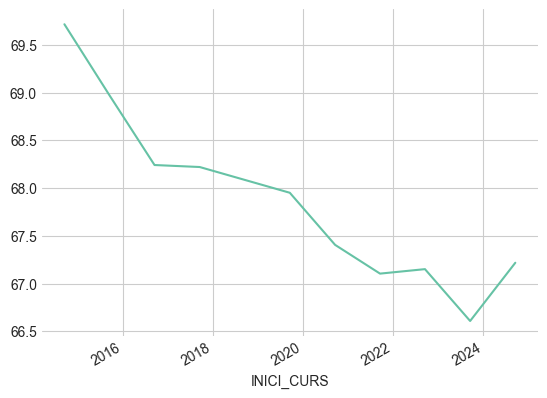

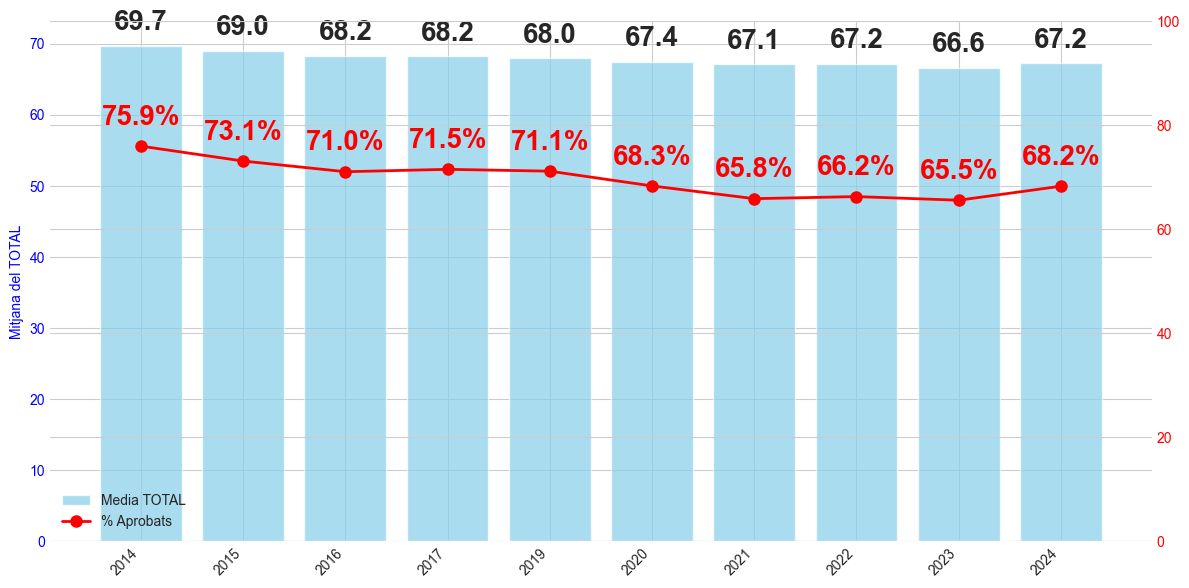


INICI_CURS      Media TOTAL  % Aprobados  Total Alumnos
2014-09         69.72        75.9         38449       
2015-09         68.97        73.1         36798       
2016-09         68.24        71.0         36424       
2017-09         68.22        71.5         58115       
2019-09         67.95        71.1         17320       
2020-09         67.41        68.3         25860       
2021-09         67.10        65.8         20254       
2022-09         67.15        66.2         17358       
2023-09         66.61        65.5         16461       
2024-09         67.22        68.2         9948        


In [127]:
df_aprovats_general=df_principal.groupby(['INICI_CURS'])['TOTAL'].mean()
df_aprovats_general.plot.line()
df=df_principal.copy()
#############################################
# Versión simplificada que evita problemas con tipos de datos

# Primero veamos qué tipo de datos tenemos
print("Tipo de datos de INICI_CURS:", df['INICI_CURS'].dtype)
print("\nPrimeros valores de INICI_CURS:")
print(df['INICI_CURS'].head())

# Si parece ser fecha (ej: '2020-09', '2021-09'), intentamos convertir
try:
    df['INICI_CURS_dt'] = pd.to_datetime(df['INICI_CURS'], errors='coerce')
    # Si la conversión funciona bien, usamos esta columna
    df['INICI_CURS'] = df['INICI_CURS_dt'].dt.strftime('%Y-%m')
    df.drop('INICI_CURS_dt', axis=1, inplace=True)
    print("\nConvertido a formato fecha")
except:
    print("\nNo se pudo convertir a fecha, usando como texto")
    df['INICI_CURS'] = df['INICI_CURS'].astype(str)

# Ahora procedemos con los cálculos
df_grouped = df.groupby('INICI_CURS').agg(
    media_TOTAL=('TOTAL', 'mean'),
    total_alumnos=('TOTAL', 'count'),
    aprobados=('TOTAL', lambda x: (x > 64).sum())
).reset_index()

df_grouped['porcentaje_aprobados'] = (df_grouped['aprobados'] / df_grouped['total_alumnos'] * 100)

# Ordenar por INICI_CURS
try:
    df_grouped = df_grouped.sort_values('INICI_CURS')
except:
    pass

# Crear gráfico simple pero efectivo
fig, ax1 = plt.subplots(figsize=(12, 6))

# Barras para media TOTAL
x_pos = range(len(df_grouped))
ax1.bar(x_pos, df_grouped['media_TOTAL'], color='skyblue', alpha=0.7, label='Media TOTAL')
#ax1.set_xlabel('Inicio del Curso')
ax1.set_ylabel('Mitjana del TOTAL', color='blue')
ax1.tick_params(axis='y', labelcolor='blue')

# Línea para % aprobados
ax2 = ax1.twinx()
ax2.plot(x_pos, df_grouped['porcentaje_aprobados'], 
         color='red', marker='o', linewidth=2, markersize=8, 
         label='% Aprobats')
#ax2.set_ylabel('% de Aprobados (TOTAL > 64)', color='red')
ax2.tick_params(axis='y', labelcolor='red')

ax2.set_ylim(0, 100)

# Configurar eje x
ax1.set_xticks(x_pos)
#ax1.set_xticklabels(df_grouped['INICI_CURS'], rotation=45, ha='right')
labels_year = df_grouped['INICI_CURS'].str[:4]
ax1.set_xticklabels(labels_year, rotation=45, ha='right')

# Título
#plt.title('Evolución del Rendimiento por Curso\nMedia TOTAL y % de Aprobados', fontweight='bold')

# Leyenda
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='best')

# Añadir valores
for i, (media, porcentaje) in enumerate(zip(df_grouped['media_TOTAL'], df_grouped['porcentaje_aprobados'])):
    ax1.text(i, media + max(df_grouped['media_TOTAL'])*0.02, f'{media:.1f}', 
             ha='center', va='bottom', fontweight='bold',fontsize=20)
    ax2.text(i, porcentaje + 3, f'{porcentaje:.1f}%', 
             ha='center', va='bottom', color='red', fontweight='bold',fontsize=20)

plt.tight_layout()
#plt.savefig('C:\\temp\\grafic_evolucio_global.png',dpi=1200)
plt.show()

# Mostrar resultados
print("\n" + "="*70)
print(f"{'INICI_CURS':<15} {'Media TOTAL':<12} {'% Aprobados':<12} {'Total Alumnos':<12}")
print("="*70)
for _, row in df_grouped.iterrows():
    print(f"{row['INICI_CURS']:<15} {row['media_TOTAL']:<12.2f} {row['porcentaje_aprobados']:<12.1f} {row['total_alumnos']:<12}")

## Miro el % d'aprovats ponderat per sexe 

### DONES i HOMES

RESUMEN DE RESULTADOS POR SEXO

MUJERES:
  Total estudiantes: 156345
  Aprobados: 110270
  Porcentaje aprobados: 70.5%
  Porcentaje no aprobados: 29.5%

HOMBRES:
  Total estudiantes: 120642
  Aprobados: 85577
  Porcentaje aprobados: 70.9%
  Porcentaje no aprobados: 29.1%
Porcentaje de mujeres aprobadas: 70.52991780997154%
Porcentaje de hombres aprobados: 70.93466620248337%
Porcentaje de mujeres no aprobadas: 29.470082190028464%
Porcentaje de hombres no aprobados: 29.06533379751663%


C:\Users\Usuario\AppData\Local\Temp\ipykernel_58588\3223708020.py:158: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


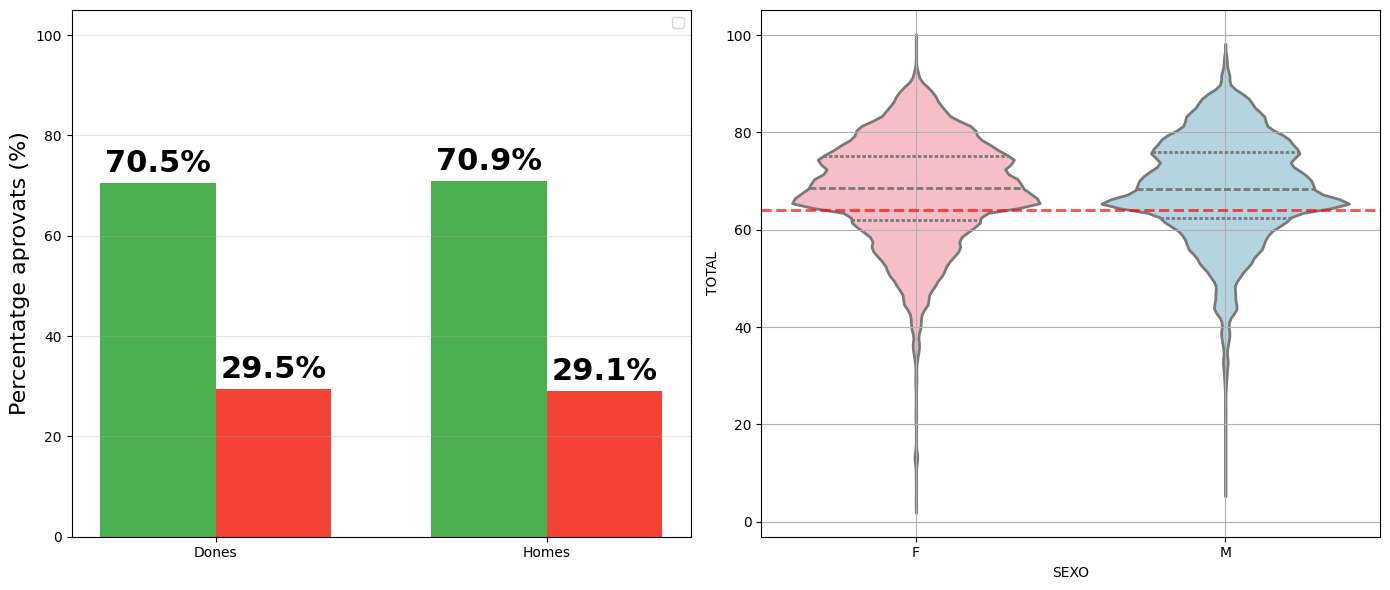


TABLA RESUMEN
   Sexo                 Categoría  Porcentaje  Cantidad  Total grupo
Mujeres    Aprobados (TOTAL > 64)   70.529918    110270       156345
Mujeres No Aprobados (TOTAL ≤ 64)   29.470082     46075       156345
Hombres    Aprobados (TOTAL > 64)   70.934666     85577       120642
Hombres No Aprobados (TOTAL ≤ 64)   29.065334     35065       120642


In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
df=df_principal.copy()


# 1. Calcular métricas para ambos sexos
resultados = []

for sexo in ['F', 'M']:
    grupo = df[df['SEXO'] == sexo]
    total_grupo = len(grupo)
    aprobados = len(grupo[grupo['TOTAL'] > 64])
    no_aprobados = total_grupo - aprobados
    
    if total_grupo > 0:
        porcentaje_aprobados = (aprobados / total_grupo) * 100
        porcentaje_no_aprobados = 100 - porcentaje_aprobados
    else:
        porcentaje_aprobados = 0
        porcentaje_no_aprobados = 0
    
    resultados.append({
        'Sexo': 'Mujeres' if sexo == 'F' else 'Hombres',
        'Categoría': 'Aprobados (TOTAL > 64)',
        'Porcentaje': porcentaje_aprobados,
        'Cantidad': aprobados,
        'Total grupo': total_grupo
    })
    
    resultados.append({
        'Sexo': 'Mujeres' if sexo == 'F' else 'Hombres',
        'Categoría': 'No Aprobados (TOTAL ≤ 64)',
        'Porcentaje': porcentaje_no_aprobados,
        'Cantidad': no_aprobados,
        'Total grupo': total_grupo
    })

df_resultados = pd.DataFrame(resultados)

# Mostrar resultados numéricos
print("=" * 60)
print("RESUMEN DE RESULTADOS POR SEXO")
print("=" * 60)

for sexo in ['Mujeres', 'Hombres']:
    datos_sexo = df_resultados[df_resultados['Sexo'] == sexo]
    aprobados = datos_sexo[datos_sexo['Categoría'] == 'Aprobados (TOTAL > 64)']
    total_grupo = datos_sexo['Total grupo'].iloc[0]
    
    print(f"\n{sexo.upper()}:")
    print(f"  Total estudiantes: {total_grupo}")
    print(f"  Aprobados: {aprobados['Cantidad'].iloc[0]}")
    print(f"  Porcentaje aprobados: {aprobados['Porcentaje'].iloc[0]:.1f}%")
    print(f"  Porcentaje no aprobados: {100 - aprobados['Porcentaje'].iloc[0]:.1f}%")
    
# 6. Gráfico adicional: Comparación lado a lado
plt.figure(figsize=(14, 6))

# Gráfico 1: Porcentajes de aprobación comparativos
plt.subplot(1, 2, 1)

# ============================================================================
# PASO 1: DEFINIR CONSTANTES PARA EVITAR "MAGIC STRINGS" (cadenas mágicas)
# ============================================================================

# Definir constantes para los valores que se repiten en el código
SEXO_MUJERES = 'Mujeres'
SEXO_HOMBRES = 'Hombres'
CATEGORIA_APROBADOS = 'Aprobados (TOTAL > 64)'
CATEGORIA_NO_APROBADOS = 'No Aprobados (TOTAL ≤ 64)'
COLUMNA_SEXO = 'Sexo'
COLUMNA_CATEGORIA = 'Categoría'
COLUMNA_PORCENTAJE = 'Porcentaje'

# ============================================================================
# PASO 2: EXTRAER LOS VALORES UNO POR UNO CON EXPLICACIONES
# ============================================================================

# 2.1 Extraer el porcentaje de MUJERES APROBADAS
# ----------------------------------------------------------
# Filtro: Buscar en df_resultados las filas donde:
#   - Sexo sea 'Mujeres'
#   - Categoría sea 'Aprobados (TOTAL > 64)'
# Luego tomar la columna 'Porcentaje' y el primer valor [0]

# Crear filtro para mujeres aprobadas
filtro_mujeres_aprobadas = (df_resultados[COLUMNA_SEXO] == SEXO_MUJERES) & \
                           (df_resultados[COLUMNA_CATEGORIA] == CATEGORIA_APROBADOS)

# Aplicar filtro y obtener el valor
porcentaje_mujeres_aprobadas = df_resultados.loc[filtro_mujeres_aprobadas, COLUMNA_PORCENTAJE].iloc[0]

print(f"Porcentaje de mujeres aprobadas: {porcentaje_mujeres_aprobadas}%")

# 2.2 Extraer el porcentaje de HOMBRES APROBADOS
# ----------------------------------------------------------
filtro_hombres_aprobados = (df_resultados[COLUMNA_SEXO] == SEXO_HOMBRES) & \
                          (df_resultados[COLUMNA_CATEGORIA] == CATEGORIA_APROBADOS)

porcentaje_hombres_aprobados = df_resultados.loc[filtro_hombres_aprobados, COLUMNA_PORCENTAJE].iloc[0]

print(f"Porcentaje de hombres aprobados: {porcentaje_hombres_aprobados}%")

# 2.3 Extraer el porcentaje de MUJERES NO APROBADAS
# ----------------------------------------------------------
filtro_mujeres_no_aprobadas = (df_resultados[COLUMNA_SEXO] == SEXO_MUJERES) & \
                             (df_resultados[COLUMNA_CATEGORIA] == CATEGORIA_NO_APROBADOS)

porcentaje_mujeres_no_aprobadas = df_resultados.loc[filtro_mujeres_no_aprobadas, COLUMNA_PORCENTAJE].iloc[0]

print(f"Porcentaje de mujeres no aprobadas: {porcentaje_mujeres_no_aprobadas}%")

# 2.4 Extraer el porcentaje de HOMBRES NO APROBADOS
# ----------------------------------------------------------
filtro_hombres_no_aprobados = (df_resultados[COLUMNA_SEXO] == SEXO_HOMBRES) & \
                             (df_resultados[COLUMNA_CATEGORIA] == CATEGORIA_NO_APROBADOS)

porcentaje_hombres_no_aprobados = df_resultados.loc[filtro_hombres_no_aprobados, COLUMNA_PORCENTAJE].iloc[0]

print(f"Porcentaje de hombres no aprobados: {porcentaje_hombres_no_aprobados}%")

# ============================================================================
# PASO 3: CREAR EL DATAFRAME COMPARATIVO DE FORMA CLARA
# ============================================================================

# Crear el DataFrame con los valores extraídos
df_comparativo = pd.DataFrame({
    'Sexo': [SEXO_MUJERES, SEXO_HOMBRES],
    'Aprobados': [porcentaje_mujeres_aprobadas, porcentaje_hombres_aprobados],
    'No Aprobados': [porcentaje_mujeres_no_aprobadas, porcentaje_hombres_no_aprobados]
})


# Graficar barras agrupadas
x = np.arange(len(df_comparativo['Sexo']))
width = 0.35

bars1 = plt.bar(x - width/2, df_comparativo['Aprobados'], width,color='#4CAF50')
bars2 = plt.bar(x + width/2, df_comparativo['No Aprobados'], width,color='#F44336')#,label='No Aprobados', color='#F44336', edgecolor='black')

# Añadir valores en las barras
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2., height + 1,
                f'{height:.1f}%', ha='center', va='bottom', fontsize=22,fontweight='bold')
        

#plt.title('Comparación de Porcentajes por Sexo', fontsize=14, fontweight='bold')
#plt.xlabel('Sexo', fontsize=12)
plt.ylabel('Percentatge aprovats (%)', fontsize=16)

#plt.xticks(x, df_comparativo['Sexo'])
plt.xticks(x, ['Dones', 'Homes'])  # En lugar de df_comparativo['Sexo']
plt.ylim(0, 105)
plt.legend()
plt.grid(axis='y', alpha=0.3)

# Gráfico 2: Distribución de puntajes por sexo
plt.subplot(1, 2, 2)

# Crear violin plot
sns.violinplot(data=df, x='SEXO', y='TOTAL', 
               hue='SEXO', palette={'F': '#FFB6C1', 'M': '#ADD8E6'},
               inner='quartile', linewidth=2)

# Añadir línea de corte
plt.axhline(y=64, color='red', linestyle='--', linewidth=2, 
            label='límit per aprovar', alpha=0.7)

plt.grid(True,'major')
plt.tight_layout()
plt.savefig("C:\\LLUIS\Dropbox\\IT ACADEMY\\\Sprint13\\grafic_aprovats_sexe.png",dpi=1200)
plt.show()

# 7. Mostrar tabla resumen
print("\n" + "=" * 60)
print("TABLA RESUMEN")
print("=" * 60)
print(df_resultados[['Sexo', 'Categoría', 'Porcentaje', 'Cantidad', 'Total grupo']].to_string(index=False))

### Miro el % escola publica / no publica

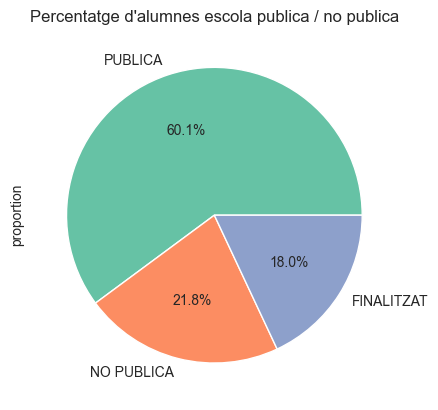

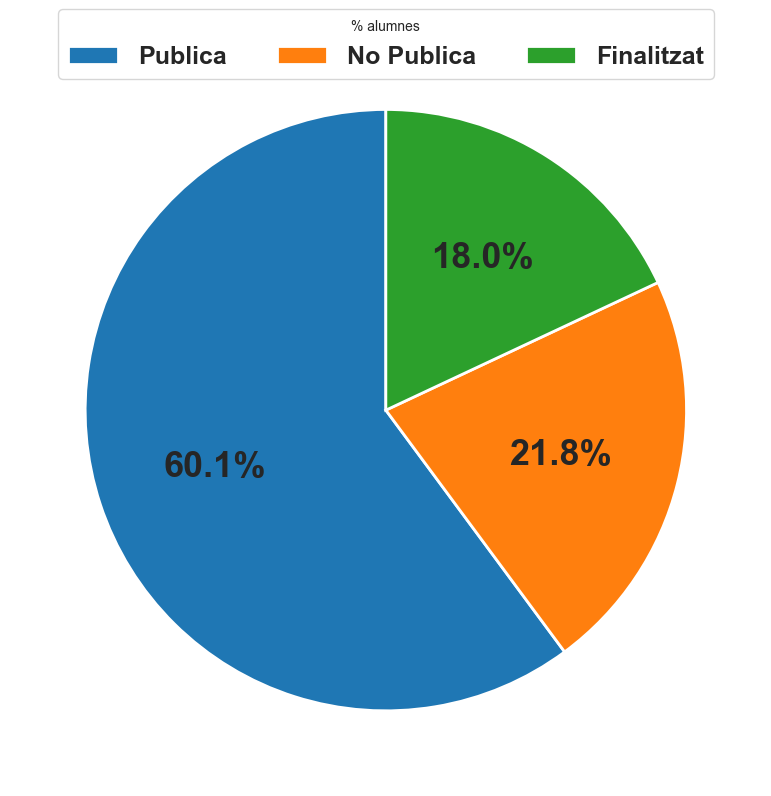

In [9]:
df_escola_pub=df_principal['TIPUS_ESCOLA'].value_counts(normalize=True) * 100
df_escola_pub.plot.pie(title='Percentatge d\'alumnes escola publica / no publica', autopct='%1.1f%%')
df_escola_pub.to_excel('C:\\temp\\df_escola.xlsx', index=False)
#####################################
# Versión minimalista para tipo de escuela
import matplotlib.pyplot as plt

# Calcular porcentajes
df_escola_pub = df_principal['TIPUS_ESCOLA'].value_counts(normalize=True) * 100

# Limpiar etiquetas
df_escola_pub.index = df_escola_pub.index.str.strip().str.title()

# Colores armoniosos
#colores = ['#3498db', '#e74c3c', '#2ecc71', '#f39c12', '#9b59b6']
#colores = ['#2E86AB', '#A23B72', '#F18F01']  # Azul, Rosa, Naranja
colores = ['#1F77B4', '#FF7F0E', '#2CA02C']  # Azul, Naranja, Verde
colores = colores[:len(df_escola_pub)]

# Gráfico simple pero elegante
plt.figure(figsize=(10, 8))

plt.pie(
    df_escola_pub.values,
    #labels= None #[f'{label} ({pct:.1f}%)' for label, pct in zip(df_escola_pub.index, df_escola_pub.values)],
    colors=colores,
    autopct='%1.1f%%',
    startangle=90,
    textprops={'fontsize':26,'fontweight': 'bold'},    
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)

#plt.title(
#    'Distribución por Tipo de Escuela',
#    fontsize=16,
#    fontweight='bold',
#    pad=20
#)

# Añadir total en la leyenda
# Leyenda arriba
plt.legend(
    df_escola_pub.index,  # Nombres de las categorías en la leyenda
    title='% alumnes',
    loc='upper center',  # Colocamos la leyenda arriba
    bbox_to_anchor=(0.5, 1.05),  # Ajusta la posición vertical de la leyenda
    ncol=len(df_escola_pub),  # Si quieres que las categorías estén en una fila
    frameon=True,
    framealpha=0.8,
    title_fontsize='medium',
    prop={'weight': 'bold', 'size': 18}  # Leyenda en negrita y tamaño más grande
)


plt.tight_layout()
#plt.savefig('C:\\temp\\grafico_escuela_minimalista.png',dpi=1200)
plt.show()

# Guardar datos
df_escola_pub.to_excel('C:\\temp\\df_escola.xlsx', index=True)
#######################################

## Miro el % d'aprovats per TIPUS_ESCOLA

# 8. Gráfico circular (pie chart) para cada tipo de escuela

Categorías de TIPUS_ESCOLA encontradas: ['PUBLICA' 'FINALITZAT' 'NO PUBLICA']

RESUMEN DE RESULTADOS POR TIPO DE ESCUELA


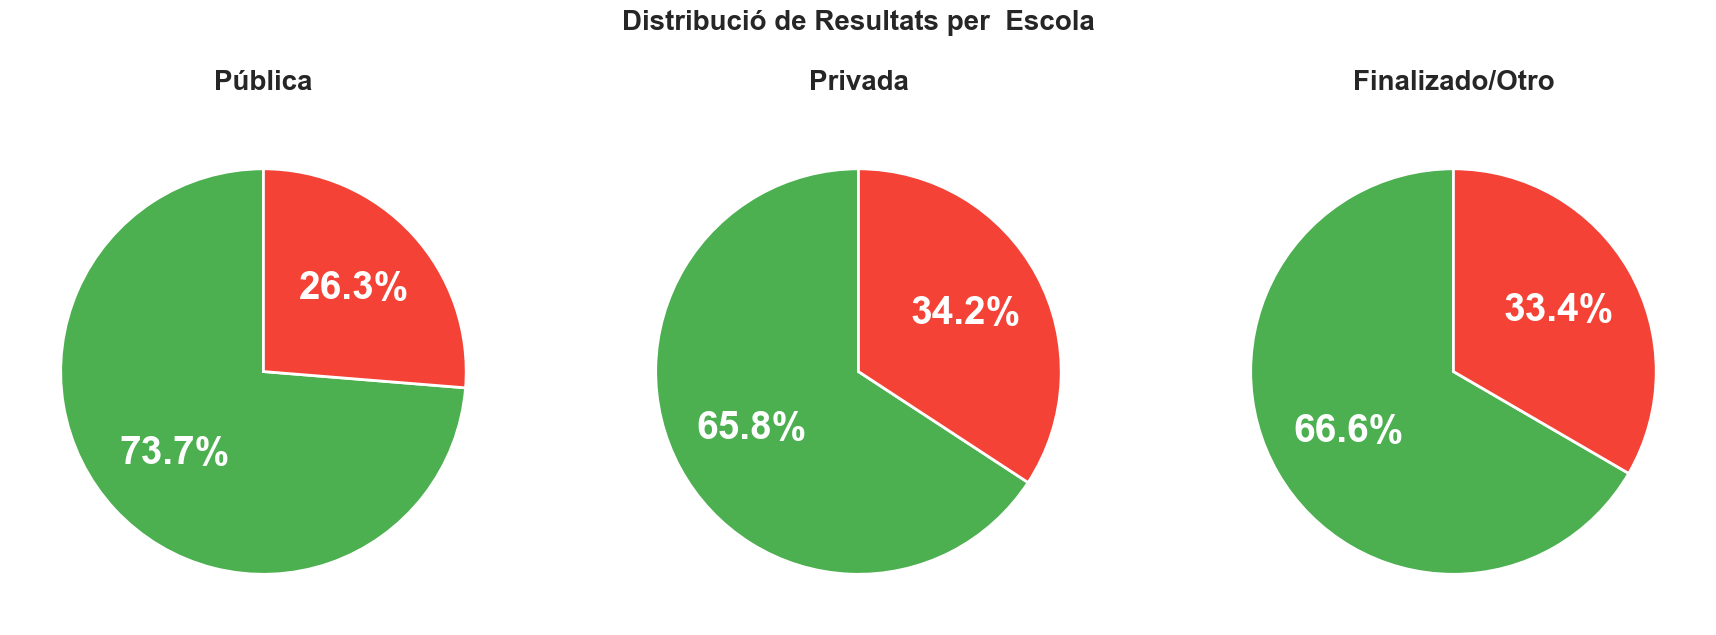

In [8]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np



df = df_principal.copy()

# Limpiar y estandarizar categorías de TIPUS_ESCOLA
df['TIPUS_ESCOLA'] = df['TIPUS_ESCOLA'].str.upper().str.strip()

# Verificar categorías únicas
categorias = df['TIPUS_ESCOLA'].unique()
print(f"Categorías de TIPUS_ESCOLA encontradas: {categorias}")

# 1. Calcular métricas para cada tipo de escuela
resultados = []

for tipo in sorted(categorias):
    grupo = df[df['TIPUS_ESCOLA'] == tipo]
    total_grupo = len(grupo)
    aprobados = len(grupo[grupo['TOTAL'] > 64])
    no_aprobados = total_grupo - aprobados
    
    if total_grupo > 0:
        porcentaje_aprobados = (aprobados / total_grupo) * 100
        porcentaje_no_aprobados = 100 - porcentaje_aprobados
    else:
        porcentaje_aprobados = 0
        porcentaje_no_aprobados = 0
    
    # Traducir categorías a español para mejor visualización
    tipo_traducido = {
        'PUBLICA': 'Pública',
        'NO PUBLICA': 'Privada',
        'FINALITZAT': 'Finalizado/Otro'
    }.get(tipo, tipo)
    
    resultados.append({
        'Tipo de Escuela': tipo_traducido,
        'Categoría': 'Aprobados (TOTAL > 64)',
        'Porcentaje': porcentaje_aprobados,
        'Cantidad': aprobados,
        'Total grupo': total_grupo,
        'Categoria_original': tipo
    })
    
    resultados.append({
        'Tipo de Escuela': tipo_traducido,
        'Categoría': 'No Aprobados (TOTAL ≤ 64)',
        'Porcentaje': porcentaje_no_aprobados,
        'Cantidad': no_aprobados,
        'Total grupo': total_grupo,
        'Categoria_original': tipo
    })

df_resultados = pd.DataFrame(resultados)

# Ordenar por tipo de escuela (orden personalizado)
orden_tipos = ['Pública', 'Privada', 'Finalizado/Otro']
df_resultados['Tipo de Escuela'] = pd.Categorical(
    df_resultados['Tipo de Escuela'], 
    categories=orden_tipos, 
    ordered=True
)
df_resultados = df_resultados.sort_values('Tipo de Escuela')

# Mostrar resultados numéricos
print("\n" + "=" * 70)
print("RESUMEN DE RESULTADOS POR TIPO DE ESCUELA")
print("=" * 70)

# 8. Gráfico circular (pie chart) para cada tipo de escuela
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for idx, tipo in enumerate(orden_tipos):
    if tipo in df_resultados['Tipo de Escuela'].unique():
        datos_tipo = df_resultados[df_resultados['Tipo de Escuela'] == tipo]
        
        # Extraer porcentajes
        aprobados_pct = datos_tipo[datos_tipo['Categoría'] == 'Aprobados (TOTAL > 64)']['Porcentaje'].iloc[0]
        no_aprobados_pct = 100 - aprobados_pct
        
        # Extraer cantidades
        aprobados_cant = datos_tipo[datos_tipo['Categoría'] == 'Aprobados (TOTAL > 64)']['Cantidad'].iloc[0]
        total_cant = datos_tipo['Total grupo'].iloc[0]
        
        # Crear pie chart
        wedges, texts, autotexts = axes[idx].pie(
            [aprobados_pct, no_aprobados_pct],
            #labels=['Aprobados', 'No Aprobados'],
            autopct='%1.1f%%',
            colors=['#4CAF50', '#F44336'],
            startangle=90,
            wedgeprops=dict(edgecolor='white', linewidth=2),
            textprops={'fontsize': 28, 'fontweight': 'bold'}
        )
        
        # Personalizar texto
        for autotext in autotexts:
            autotext.set_color('white')
            autotext.set_fontweight('bold')
        
        axes[idx].set_title(f'{tipo}', 
                          fontsize=20, fontweight='bold', pad=20)
        
        

plt.suptitle('Distribució de Resultats per  Escola', 
             fontsize=20, fontweight='bold', y=1.05)
#plt.savefig("C:\\temp\\grafic_aprovat_per_escola.png",dpi=1200)
plt.tight_layout()
plt.show()

### Miro el % d'aprovats (TOTAL>=65) per sexe

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Calcular el percentatge d'aprovats per sexe
df_aprovats = df_principal[df_principal["TOTAL"] >= 65]
percent_aprovats = (
    df_aprovats.groupby("SEXO").size() / df_principal.groupby("SEXO").size() * 100
).reset_index(name="Percent_Aprovats")

# 2. Exportar a Excel
percent_aprovats.to_excel("percentatge_aprovats_per_sexe.xlsx", index=False)

# 3. Crear boxplot amb seaborn
plt.figure(figsize=(6, 4))
sns.boxplot(data=df_principal, x="SEXO", y="TOTAL", palette="Set2")
plt.title("Distribució de notes per Sexe")
plt.ylabel("Nota TOTAL")
plt.xlabel("Sexe")

# 4. Guardar el gràfic
plt.savefig("boxplot_notes_per_sexe.png", dpi=300, bbox_inches='tight')
plt.close()
df_aprovats_sexe=df_principal.query('TOTAL >= 65').groupby('SEXO')
plt.show()


In [ ]:
df_aprovats_sexe=df_principal.query('TOTAL >= 65').groupby('SEXO')
print(df_aprovats_sexe)
#df_aprovats_sexe.size().plot()#.pie(title='Percentatge d\'aprovats per sexe', autopct='%1.1f%%')

# Crear el dataframe agregat
#df_aprovats_sexe = df_principal.query('TOTAL >= 65').groupby('SEXO').size().reset_index(name='COUNT')

# Exportar a Excel
#df_aprovats_sexe.to_excel("C:\\temp\\aprovats_per_sexe.xlsx", index=False)




### Miro el % d'aprovats (TOTAL>=65) per TIPUS_ESCOLA

# matriu de coorelació de la mitja de resultats centat en la mitja

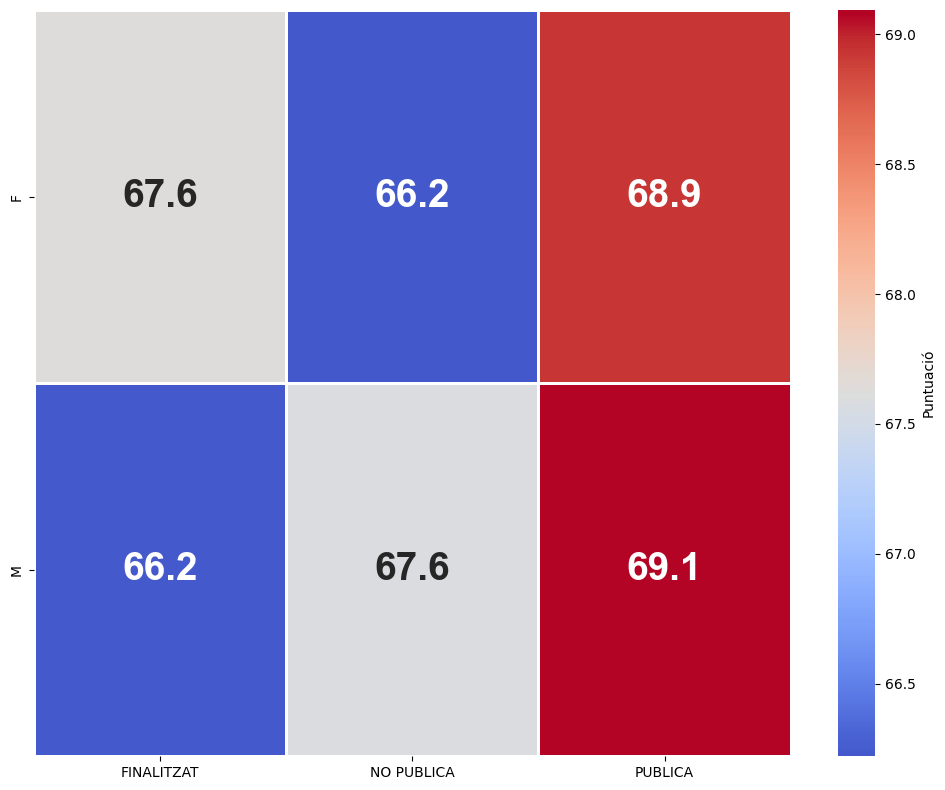

In [22]:
# Preparar datos para heatmap
df = df_principal.groupby(['TIPUS_ESCOLA', 'SEXO'])['TOTAL'].mean().reset_index()
pivot_df = df.pivot(index='SEXO', columns='TIPUS_ESCOLA', values='TOTAL')

# Calcular la media global
media_global = pivot_df.values.mean()

# Usar una escala divergente centrada en la media
plt.figure(figsize=(10, 8))

# Crear heatmap con escala centrada
ax = sns.heatmap(pivot_df, annot=True, fmt='.1f', cmap='coolwarm', 
                  linewidths=1, linecolor='white', 
                  center=media_global,  # Esto centra la escala en la media
                   cbar_kws={'label': 'Puntuació'},
                  annot_kws={
                      'size': 28,
                      'weight': 'bold',
                      'fontfamily': 'Arial'
                  })



plt.xlabel('')  
plt.ylabel('')  


plt.savefig('C:\\LLUIS\\Dropbox\\IT ACADEMY\\Sprint13\\mapa_calor_resultats_escola_sexe.png', dpi=1200)
plt.tight_layout()
plt.show()

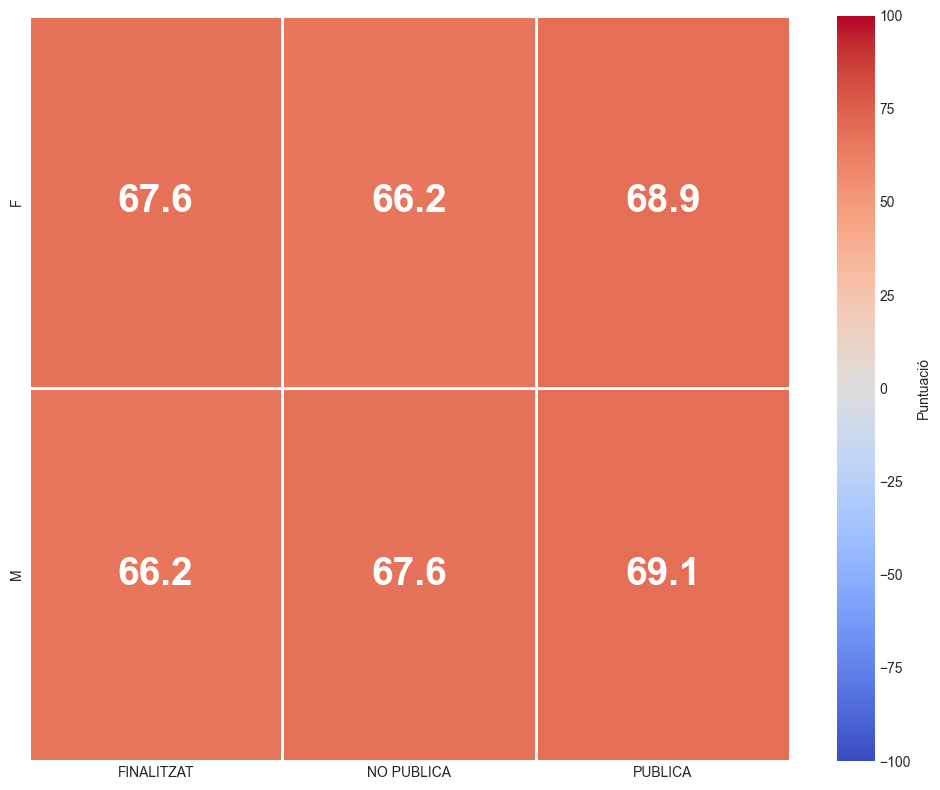

In [ ]:
# Preparar datos para heatmap
df = df_principal.groupby(['TIPUS_ESCOLA', 'SEXO'])['TOTAL'].mean().reset_index()
pivot_df = df.pivot(index='SEXO', columns='TIPUS_ESCOLA', values='TOTAL')

plt.figure(figsize=(10, 8))

# Crear heatmap
sns.heatmap(pivot_df, annot=True, fmt='.1f', cmap='coolwarm', 
            linewidths=1, linecolor='white',vmin=-100,vmax=100, cbar_kws={'label': 'Puntuació'},
            annot_kws={
                     'size': 28,
                     'weight': 'bold',
                     'fontfamily': 'Arial'
                 })
# Opcional: mantener títulos de ejes pero sin etiquetas
plt.xlabel('')  # Eliminar etiqueta del eje X
plt.ylabel('')  # Eliminar etiqueta del eje Y
#plt.title('Mapa de Calor - Resultados por Materia y Género',fontsize=16, fontweight='bold', pad=20)
plt.savefig('C:\\LLUIS\\Dropbox\\IT ACADEMY\\Sprint13\\mapa_calor_resultats_escola_sexe.png', dpi=1200)
plt.tight_layout()

plt.show()

# Graficos plotly

In [15]:
# Importar plotly.graph_objects si no lo has hecho
import plotly.graph_objects as go
import plotly.express as px
# Opción 4: Gráfico interactivo con múltiples trazas
fig4 = go.Figure()

materias = df_principal['MATERIA'].unique()
colores = px.colors.qualitative.Set1

for i, materia in enumerate(materias):
    df_materia = df[df['MATERIA'] == materia]
    fig4.add_trace(go.Scatter(
        x=df_materia['DATA_EVALUACIO'],
        y=df_materia['RESULT'],
        name=materia,
        mode='lines+markers',
        line=dict(color=colores[i % len(colores)], width=3),
        marker=dict(size=8)
    ))

fig4.update_layout(
    #title='Evolución Detallada por Materia',
    #xaxis_title='Evaluación',
    yaxis_title='Puntuación Total',
    yaxis=dict(range=[5, 20]),
    hovermode='closest'
)
"""
fig4.write_html(
    "C:\\temp\img\\grafico_interactivo_MATERIAS.html",
    include_plotlyjs='cdn',  # Usa CDN en lugar de incluir toda la librería
    config={
        'responsive': True,
        'displaylogo': False
    }
)
"""
fig4.show()